In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer

df = pd.read_csv('retail_fraud_detection_100k.csv')

In [2]:
feature_cols = ['transaction_amount', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'high_risk_device_flag', 'velocity_flag']
drop_cols = ['transaction_id', 'customer_id', 'transaction_timestamp']
df = df.drop(columns = drop_cols)

correlations = df[feature_cols + ['fraud_flag']].corr()['fraud_flag'].abs().sort_values(ascending = False)
print("Top correlations with fraud_flag:")
print(correlations)

top_3 = ['previous_fraud_flag', 'is_international', 'unusual_location_flag']

X = df[top_3]
y = df['fraud_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Top correlations with fraud_flag:
fraud_flag                          1.000000
previous_fraud_flag                 0.423561
is_international                    0.422911
unusual_location_flag               0.422911
multiple_transactions_short_time    0.348364
unusual_amount_flag                 0.329398
velocity_flag                       0.326297
transaction_frequency_24h           0.324047
failed_transaction_count_24h        0.228550
transaction_amount                  0.206105
avg_transaction_amount_7d           0.138906
high_risk_device_flag               0.126393
account_age_days                    0.002136
Name: fraud_flag, dtype: float64


In [3]:
# always predict majority class (most frequent)
dummy = DummyClassifier(strategy = 'most_frequent', random_state = 42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Dummy Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dummy):.4f}")

Dummy Classifier:
Accuracy: 0.5181
F1 Score: 0.0000


In [4]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naïve Bayes:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_nb):.4f}")

Naïve Bayes:
Accuracy: 0.7076
F1 Score: 0.7016


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state = 42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression (scaled):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression (scaled):
Accuracy: 0.7329
F1 Score: 0.6363


In [6]:
# k = 5
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("k-NN (k = 5) Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_knn):.4f}")

k-NN (k = 5) Results:
Accuracy: 0.7076
F1 Score: 0.7016


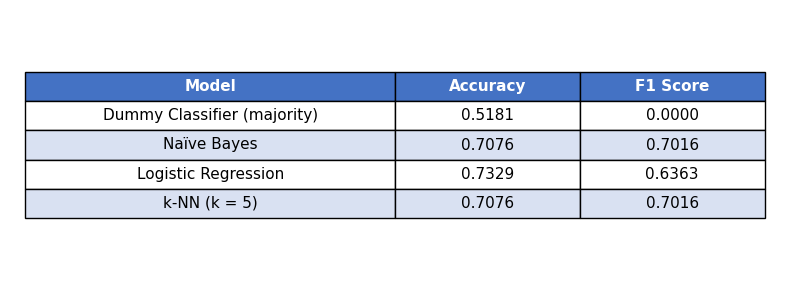

In [7]:
# Results data
data = [
    ['Model', 'Accuracy', 'F1 Score'],
    ['Dummy Classifier (majority)', '0.5181', '0.0000'],
    ['Naïve Bayes', '0.7076', '0.7016'],
    ['Logistic Regression', '0.7329', '0.6363'],
    ['k-NN (k = 5)', '0.7076', '0.7016']
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(cellText=data, loc='center', cellLoc='center', colWidths=[0.4, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

for i in range(3):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight = 'bold', color = 'white')

for i in range(1, 5):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#D9E1F2')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')

plt.tight_layout()
# plt.savefig('figure5_baseline_results.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [8]:
#--------------------------- Model ----------------------------------

In [9]:
GREEN = '\033[92m'
RESET = '\033[0m'

feature_rank = [
    'previous_fraud_flag',
    'is_international', 
    'unusual_location_flag',
    'multiple_transactions_short_time',
    'unusual_amount_flag',
    'velocity_flag',
    'transaction_frequency_24h',
    'failed_transaction_count_24h',
    'transaction_amount',
    'avg_transaction_amount_7d',
    'high_risk_device_flag',
    'account_age_days'
]

X_full = df[feature_rank]
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size = 0.2, random_state = 42)

for model_name, model in [('Naïve Bayes', GaussianNB()), ('k-NN', KNeighborsClassifier(n_neighbors = 5))]:
    print(f"\n{model_name}:")
    print("-" * 65)
    print(f"{'Features':10} {'Last added':28} {'Accuracy':10} {'F1 Score':10}")
    print("-" * 65)
    
    best_f1 = -1
    best_i = -1
    # best_acc = 0
    # best_feature = ""
    results = []
    
    for i in range(3, len(feature_rank) + 1):
        selected_features = feature_rank[:i]
        X_train_subset = X_train[selected_features]
        X_test_subset = X_test[selected_features]
        
        if model_name == 'k-NN':
            scaler = StandardScaler()
            X_train_subset = scaler.fit_transform(X_train_subset)
            X_test_subset = scaler.transform(X_test_subset)
        
        model.fit(X_train_subset, y_train)
        y_pred = model.predict(X_test_subset)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append((i, selected_features[-1], acc, f1))
        
        if f1 > best_f1:
            best_f1 = f1
            best_i = i
            best_acc = acc
            best_feature = selected_features[-1]
    
    for i, feature, acc, f1 in results:
        if i == best_i:
            print(f"{GREEN}{i:2d}   {feature:35s} {acc:.4f}     {f1:.4f}  <<< BEST{RESET}")
        else:
            print(f"{i:2d}   {feature:35s} {acc:.4f}     {f1:.4f}")
    
    print("-" * 65)



Naïve Bayes:
-----------------------------------------------------------------
Features   Last added                   Accuracy   F1 Score  
-----------------------------------------------------------------
 3   unusual_location_flag               0.7076     0.7016
 4   multiple_transactions_short_time    0.7076     0.7016
 5   unusual_amount_flag                 0.8673     0.8611
 6   velocity_flag                       0.9049     0.9060  <<< BEST
 7   transaction_frequency_24h           0.8639     0.8620
 8   failed_transaction_count_24h        0.8880     0.8863
 9   transaction_amount                  0.8717     0.8664
10   avg_transaction_amount_7d           0.8749     0.8694
11   high_risk_device_flag               0.8681     0.8609
12   account_age_days                    0.8681     0.8608
-----------------------------------------------------------------

k-NN:
-----------------------------------------------------------------
Features   Last added                   Accuracy   F1

In [10]:
nb_optimal_features = feature_rank[:6]  
knn_optimal_features = feature_rank[:11]

categorical_cols = ['device_type', 'merchant_category', 'payment_method', 'location']

print("=" * 70)
print("Adding Categorical Features One by One (k-NN)")
print("=" * 70)

knn_results = []
current_features = knn_optimal_features.copy()

X_train, X_test, y_train, y_test = train_test_split(df[current_features], y, test_size = 0.2, random_state = 42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
baseline_f1 = f1_score(y_test, y_pred)
print(f"\nBaseline (numerical only): F1 = {baseline_f1:.4f}")
knn_results.append(('baseline', baseline_f1))

for cat in categorical_cols:
    current_features = knn_optimal_features + [cat]
    X = df[current_features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)
    
    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(drop = 'first', sparse_output = False), [cat])],
        remainder='passthrough'
    )
    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)
    
    # Scale for k-NN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_encoded)
    X_test_scaled = scaler.transform(X_test_encoded)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    print(f"Baseline + {cat}: F1 = {f1:.4f}")
    knn_results.append((cat, f1))

print("\n" + "=" * 70)
print("Adding Categorical Features One by One (Naïve Bayes)")
print("=" * 70)

# Naïve Bayes
nb_results = []
current_features = nb_optimal_features.copy()

X_train, X_test, y_train, y_test = train_test_split(df[current_features], y, test_size = 0.2, random_state = 42)
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
baseline_f1 = f1_score(y_test, y_pred)
print(f"\nBaseline (numerical only): F1 = {baseline_f1:.4f}")
nb_results.append(('baseline', baseline_f1))

for cat in categorical_cols:
    current_features = nb_optimal_features + [cat]
    X = df[current_features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
    
    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(drop = 'first', sparse_output = False), [cat])],
        remainder='passthrough'
    )
    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)
    
    nb = GaussianNB()
    nb.fit(X_train_encoded, y_train)
    y_pred = nb.predict(X_test_encoded)
    f1 = f1_score(y_test, y_pred)
    print(f"Baseline + {cat}: F1 = {f1:.4f}")
    nb_results.append((cat, f1))

Adding Categorical Features One by One (k-NN)

Baseline (numerical only): F1 = 0.9999
Baseline + device_type: F1 = 0.9992
Baseline + merchant_category: F1 = 0.9980
Baseline + payment_method: F1 = 0.9984
Baseline + location: F1 = 0.9976

Adding Categorical Features One by One (Naïve Bayes)

Baseline (numerical only): F1 = 0.9060
Baseline + device_type: F1 = 0.9060
Baseline + merchant_category: F1 = 0.9060
Baseline + payment_method: F1 = 0.9060
Baseline + location: F1 = 0.9060
